# **Spotify Dataset — Machine Learning and Feature Importance Analysis**

## **Import Libraries**

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from datetime import datetime
import pickle
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

**A fixed random state is used to ensure reproducibility of machine learning experiments.**

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

## **Project path Configuration**

In [3]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "cleaned_data.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

CLEANED_DATA_PATH = PROJECT_ROOT / "data" / "cleaned_data.csv"

## **Load Cleaned Dataset**

In [4]:
df = pd.read_csv(CLEANED_DATA_PATH)

## **Dataset Overview**

In [5]:
df.shape

(88237, 20)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 88237 entries, 0 to 88236
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          88237 non-null  str    
 1   artists           88237 non-null  str    
 2   album_name        88237 non-null  str    
 3   track_name        88237 non-null  str    
 4   popularity        88237 non-null  float64
 5   duration_ms       88237 non-null  float64
 6   explicit          88237 non-null  bool   
 7   danceability      88237 non-null  float64
 8   energy            88237 non-null  float64
 9   key               88237 non-null  int64  
 10  loudness          88237 non-null  float64
 11  mode              88237 non-null  int64  
 12  speechiness       88237 non-null  float64
 13  acousticness      88237 non-null  float64
 14  instrumentalness  88237 non-null  float64
 15  liveness          88237 non-null  float64
 16  valence           88237 non-null  float64
 17  temp

## **Feature Engineering**
- This section applies several feature engineering and preprocessing techniques to prepare the dataset for machine learning modeling.
- The process includes creating new variables from audio features, transforming numerical attributes, categorizing musical characteristics, encoding categorical variables, and optimizing feature representations to improve predictive performance and analytical quality.

### Drop unnecessary columns

In [7]:
df = df.drop(columns=['track_id', 'track_name', 'artists', 'album_name'])

### Convert Duration to Minutes

In [8]:
# create duration in minutes
df["duration_min"] = df["duration_ms"] / 60000

# remove duplicated information
df = df.drop(columns=["duration_ms"])

### Categorize Tempo


In [9]:
if 'tempo' in df.columns:
    df['tempo_category'] = pd.cut(df['tempo'],bins=[-1, 90, 140, df['tempo'].max() + 1],labels=['slow', 'medium', 'fast'])
df[['tempo', 'tempo_category']].head()

,tempo,tempo_category
0,104.042,medium
1,178.174,fast
2,119.997,medium
3,161.721,fast
4,129.971,medium


In [10]:
 # convert to string for encoding
df['tempo_category'] = df['tempo_category'].astype('str')
df[['tempo','tempo_category']].head()

,tempo,tempo_category
0,104.042,medium
1,178.174,fast
2,119.997,medium
3,161.721,fast
4,129.971,medium


### **Create new features**

### Creating Mood Categories from Audio Features
This section creates a new feature called `mood_category` based on the combination of energy and valence scores. 

According to Spotify audio feature definitions:
- Energy reflects the intensity and activity level of a track.
- Valence reflects the musical positivity or emotional tone.

By combining these two variables, songs can be categorized into different emotional moods to support listener behavior analysis and practical interpretation.

In [11]:
def mood_category(row):
    if row['energy'] > 0.6 and row['valence'] > 0.6:
        return 'Happy/Energetic'
    
    elif row['energy'] < 0.4 and row['valence'] < 0.4:
        return 'Sad/Chill'
    
    elif row['energy'] > 0.6 and row['valence'] < 0.4:
        return 'Aggressive'

    else:
        return 'Relaxing'

df['mood_category'] = df.apply(mood_category, axis=1)



### **Encoding and Data Transformation**
This section converts categorical and boolean variables into numerical representations suitable for machine learning algorithms.
The process includes:
- Converting boolean features into integer format
- Applying one-hot encoding to categorical variables
- Transforming dummy variables into numerical types for modeling compatibility

### Convert explicit from boolean to integer

In [12]:
if "explicit" in df.columns:
    df['explicit'] = df['explicit'].astype(int) 

df[['explicit']].head()

,explicit
0,1
1,0
2,0
3,0
4,0


### Encode Categorical Variables

In [13]:
categorical_columns = ['tempo_category','mood_category','track_genre']

existing_categorical_columns = [col for col in categorical_columns if col in df.columns]

df = pd.get_dummies(df,columns=existing_categorical_columns,drop_first=True)

df.head()

,popularity,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,...,track_genre_spanish,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music
0,44.0,1,0.910,0.374,8,-9.844,0,0.1990,0.075700,0.00301,...,False,False,False,False,False,False,False,False,False,False
1,47.0,0,0.269,0.516,0,-7.361,1,0.0366,0.406000,0.00000,...,False,False,False,False,False,False,False,False,False,False
2,22.0,0,0.686,0.560,5,-13.264,0,0.0462,0.001140,0.18100,...,False,False,False,False,False,False,False,False,False,False
3,62.0,0,0.679,0.770,0,-3.537,1,0.1900,0.058300,0.00000,...,False,False,False,False,False,False,False,False,False,False
4,19.0,0,0.519,0.431,6,-13.606,0,0.0291,0.000964,0.72000,...,False,False,False,False,False,False,False,False,False,False


### Convert Boolean Dummy Columns to integer

In [14]:
bool_cols = (df.select_dtypes(include=["bool"]).columns)
df[bool_cols] = (df[bool_cols].astype(int))
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 88237 entries, 0 to 88236
Columns: 132 entries, popularity to track_genre_world-music
dtypes: float64(11), int64(121)
memory usage: 88.9 MB


### Encode Genre Categories

In [15]:
if "track_genre" in df.columns:
    df = pd.get_dummies(df, columns=['tempo_category'], drop_first=True)
df.head()

,popularity,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,...,track_genre_spanish,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music
0,44.0,1,0.910,0.374,8,-9.844,0,0.1990,0.075700,0.00301,...,0,0,0,0,0,0,0,0,0,0
1,47.0,0,0.269,0.516,0,-7.361,1,0.0366,0.406000,0.00000,...,0,0,0,0,0,0,0,0,0,0
2,22.0,0,0.686,0.560,5,-13.264,0,0.0462,0.001140,0.18100,...,0,0,0,0,0,0,0,0,0,0
3,62.0,0,0.679,0.770,0,-3.537,1,0.1900,0.058300,0.00000,...,0,0,0,0,0,0,0,0,0,0
4,19.0,0,0.519,0.431,6,-13.606,0,0.0291,0.000964,0.72000,...,0,0,0,0,0,0,0,0,0,0


## **Applying Regression Models**

### **Define Features and Target Variable**

In [16]:
if "popularity" not in df.columns:
    raise ValueError("The target column 'popularity' was not found in the dataset.")

X = df.drop(columns=["popularity"])
y = df["popularity"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Remaining non-numeric columns:", 
      X.select_dtypes(exclude=["number"]).columns.tolist())

X.head()

Features shape: (88237, 131)
Target shape: (88237,)
Remaining non-numeric columns: []


,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,...,track_genre_spanish,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music
0,1,0.910,0.374,8,-9.844,0,0.1990,0.075700,0.00301,0.1540,...,0,0,0,0,0,0,0,0,0,0
1,0,0.269,0.516,0,-7.361,1,0.0366,0.406000,0.00000,0.1170,...,0,0,0,0,0,0,0,0,0,0
2,0,0.686,0.560,5,-13.264,0,0.0462,0.001140,0.18100,0.1110,...,0,0,0,0,0,0,0,0,0,0
3,0,0.679,0.770,0,-3.537,1,0.1900,0.058300,0.00000,0.0825,...,0,0,0,0,0,0,0,0,0,0
4,0,0.519,0.431,6,-13.606,0,0.0291,0.000964,0.72000,0.0916,...,0,0,0,0,0,0,0,0,0,0


### **Train-Test Split**

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape) 

X_train: (70589, 131)
X_test: (17648, 131)


### **Feature Scaling**

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### **Train and Evaluate Machine Learning Models**

This section trains and evaluates multiple regression models to identify the most effective algorithm for predicting Spotify song popularity.

Different models are compared using several evaluation metrics:
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

Scaling is selectively applied only to models that require standardized features.
Models to use: 
- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor
- Decision Tree Regressor

### Initialize Models

In [19]:
models = {
    "Linear Regression": {"pipeline": Pipeline([("scaler", StandardScaler()),("model", LinearRegression())]),"params": {}},
    "Decision Tree Regressor": {"pipeline": Pipeline([("model", DecisionTreeRegressor(random_state=RANDOM_STATE))]),"params": {
            "model__max_depth": [5, 10, 20],
            "model__min_samples_split": [2, 5, 10]}},
    "Random Forest Regressor": {"pipeline": Pipeline([("model", RandomForestRegressor(random_state=RANDOM_STATE,n_jobs=-1))]),"params": {
            "model__n_estimators": [100,200,300],
            "model__max_depth": [None,10,20,30],
            "model__min_samples_split": [2,5,10],
            "model__min_samples_leaf": [1,2,4],
            "model__max_features": ["sqrt","log2",0.7],
            "model__bootstrap": [True]}},
    "Gradient Boosting Regressor": {"pipeline": Pipeline([("model", GradientBoostingRegressor(random_state=RANDOM_STATE))]),"params": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__max_depth": [3, 5]}}}

### Train and Evaluate Models

In this section, all machine learning models are trained using the training dataset and evaluated using the testing dataset.

Each model generates predictions on unseen data, and several regression evaluation metrics are calculated to assess model performance:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

The evaluation results and trained models are stored for further comparison and analysis.

In [20]:
results = {}

trained_models = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")
    pipeline = model["pipeline"]
    pipeline.fit(X_train, y_train)
    trained_models[model_name] = pipeline

    # predictions
    y_pred = pipeline.predict(X_test)

    # evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # store results
    results[model_name] = {"MAE": mae,"MSE": mse,"RMSE": rmse,"R2 Score": r2}

    # store trained models
    trained_models[model_name] = pipeline

print("All models have been trained successfully.")

Training Linear Regression...
Training Decision Tree Regressor...
Training Random Forest Regressor...
Training Gradient Boosting Regressor...
All models have been trained successfully.


### Model Performance Comparison

- The evaluation results are converted into a structured DataFrame to simplify model comparison.
- The models are ranked based on R² Score to identify the best-performing algorithm.

In [21]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="R2 Score",ascending=False)
results_df

,MAE,MSE,RMSE,R2 Score
Random Forest Regressor,10.129453,225.176184,15.005872,0.472384
Linear Regression,12.143044,288.766440,16.993129,0.323384
Gradient Boosting Regressor,14.365221,322.954710,17.970941,0.243276
Decision Tree Regressor,12.892792,419.895641,20.491355,0.016131


### **Observation:**
- Based on the model comparison results, the Random Forest Regressor achieved the best overall performance among all evaluated models. It obtained the highest **R² Score** (0.4724) together with the lowest **MAE** (10.1295), **MSE** (225.1762), and **RMSE** (15.0059), indicating superior prediction accuracy and lower prediction errors.
- In comparison, **Linear Regression** showed moderate performance with a lower R² Score, suggesting that the relationship between Spotify audio features and song popularity is not purely linear. Meanwhile, **Gradient Boosting Regressor** and **Decision Tree Regressor** produced weaker predictive performance, with notably higher error values and lower explanatory power.

**Overall**, the results suggest that Random Forest is more effective at capturing complex non-linear relationships and feature interactions within the Spotify dataset. Therefore, it was selected as the best baseline model for subsequent hyperparameter tuning, analysis, and model interpretation.

### Visualize Model Performance

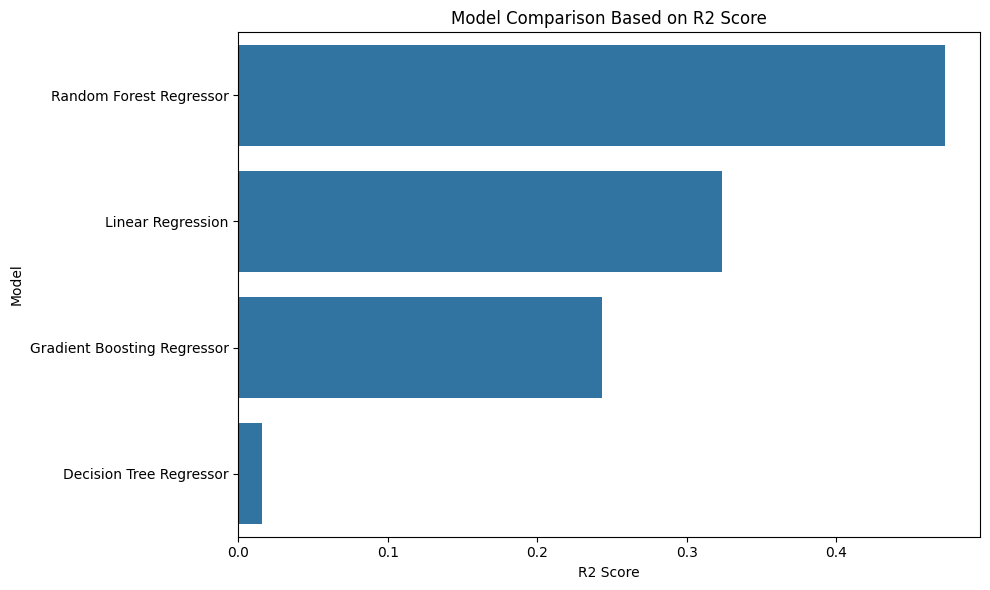

In [22]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df,x="R2 Score",y=results_df.index)
plt.title("Model Comparison Based on R2 Score")
plt.xlabel("R2 Score")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

### Select Best Model

In [23]:
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]
print(f"Best Model: {best_model_name}")


Best Model: Random Forest Regressor


### Cross-Validation
- Cross-validation is performed to evaluate the generalization ability of the best-performing model.
- This process reduces the risk of overfitting and provides a more reliable estimate of model performance.

In [24]:
print(f"Cross-Validation for {best_model_name}")

cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1)

print("CV R2 Scores:", np.round(cv_scores, 4))
print("Average CV R2:", np.mean(cv_scores))

Cross-Validation for Random Forest Regressor
CV R2 Scores: [0.4587 0.4491 0.4718 0.4635 0.4405]
Average CV R2: 0.45669892770087656


## **Hyperparameter Tuning**
RandomizedSearchCV is used to optimize the hyperparameters of the best-performing Random Forest model.

In [25]:
rf_pipeline = models["Random Forest Regressor"]["pipeline"]
rf_params = models["Random Forest Regressor"]["params"]
random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_params,
    n_iter=10,
    cv=5,
    scoring='r2',
    random_state=RANDOM_STATE,
    n_jobs=-1)
random_search.fit(X_train, y_train)
best_rf = random_search.best_estimator_
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': None, 'model__bootstrap': True}


### **Evaluate Final Model Performance**

This section evaluates the performance of the final machine learning model using regression metrics and prediction results.

In [26]:
# make final predictions
y_pred_final = best_rf.predict(X_test)

# evaluation metrics
final_mae = mean_absolute_error(y_test,y_pred_final)
final_mse = mean_squared_error(y_test,y_pred_final)
final_rmse = np.sqrt(final_mse)
final_r2 = r2_score(y_test,y_pred_final)

# create results table
final_results = pd.DataFrame({
    'Metric': [
        'MAE',
        'MSE',
        'RMSE',
        'R2 Score'],
    'Value': [
        final_mae,
        final_mse,
        final_rmse,
        final_r2]})
final_results

,Metric,Value
0,MAE,11.018411
1,MSE,234.118492
2,RMSE,15.300931
3,R2 Score,0.451431


### **Plot Actual vs Predicted Popularity**

This visualization compares actual popularity values with predicted popularity values generated by the final model.

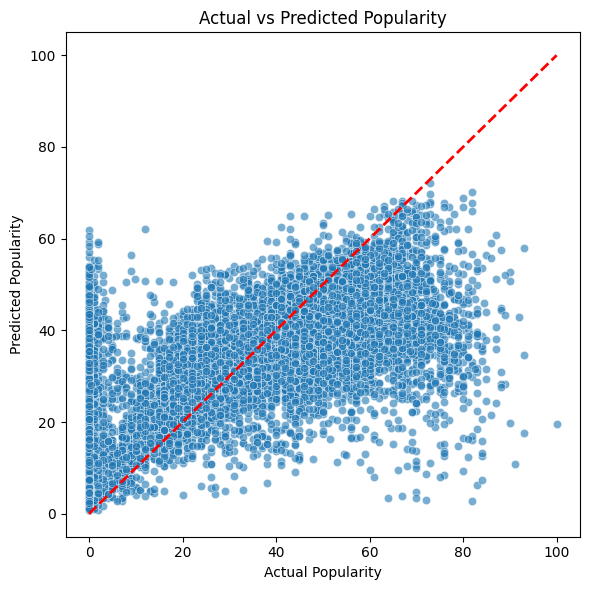

In [27]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test,y=y_pred_final,alpha=0.6)
# reference line
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],color='red',lw=2,linestyle='--')
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Actual vs Predicted Popularity")
plt.tight_layout()
plt.show()

**Observation:**
- The scatter plot shows that the model has successfully captured the overall positive relationship between actual popularity and predicted popularity, as the data points generally follow an upward trend along the diagonal reference line.
- However, the predicted values remain relatively dispersed around the diagonal reference line, indicating that prediction errors are still noticeable. In particular, the model tends to predict within a narrower range compared to the actual popularity distribution.

- Despite these limitations, the model demonstrates acceptable generalization ability and does not exhibit severe overfitting. The results suggest that music popularity is a complex phenomenon influenced not only by audio characteristics but also by external factors such as artist reputation, social media trends, playlist exposure, and marketing strategies that are not included in the current dataset.

### **Residual Analysis**

Residual analysis is performed to evaluate prediction error distribution.

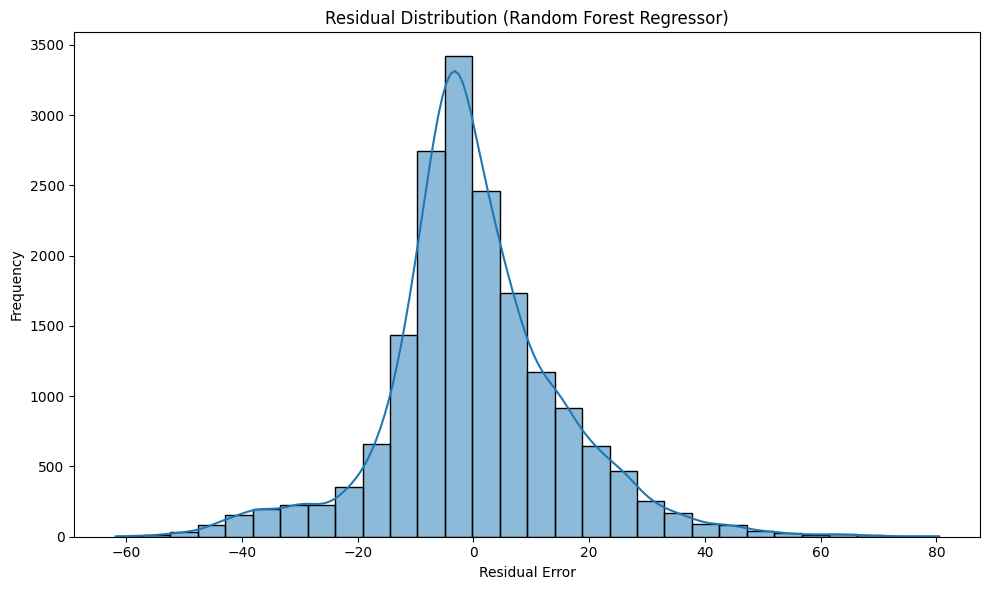

In [28]:
# predictions from best model
y_pred_best = best_rf.predict(X_test)

# calculate residuals
residuals = y_test - y_pred_best
plt.figure(figsize=(10, 6))
sns.histplot(residuals,bins=30,kde=True)
plt.title(f"Residual Distribution ({best_model_name})")
plt.xlabel("Residual Error")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Observation:**
- Residual analysis indicates that prediction errors are generally centered around zero and approximately normally distributed. This suggests that the model achieves relatively stable generalization performance and does not exhibit severe prediction bias. 
- Although a slight positive skew and several outliers are observed, the overall residual pattern remains acceptable for a real-world regression problem.

### **Feature Importance Analysis**

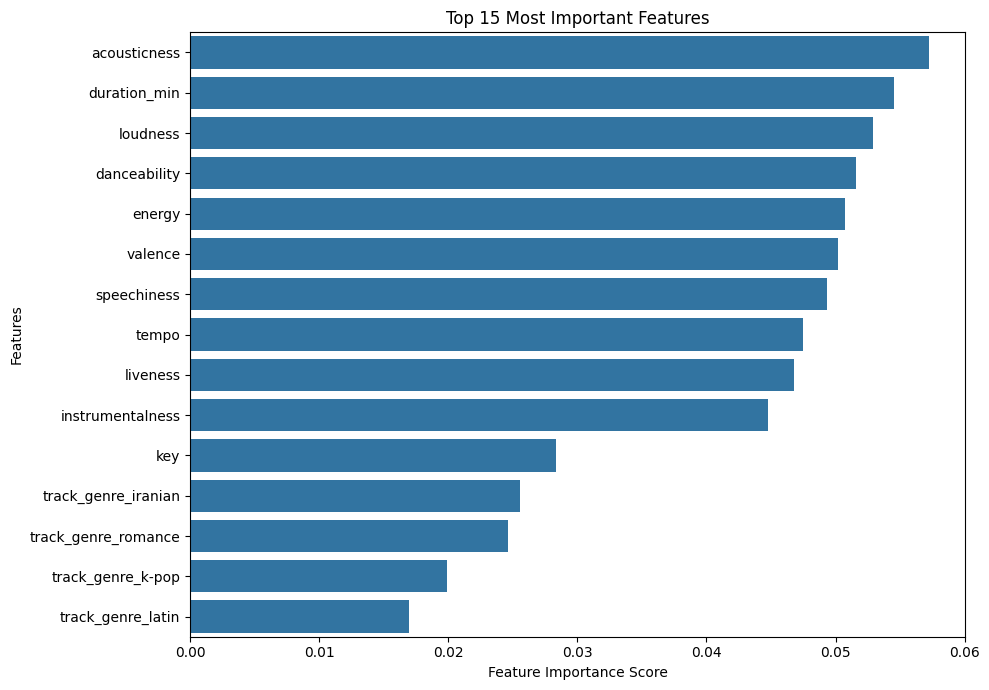

,Feature,Importance
7,acousticness,0.057205
13,duration_min,0.054497
4,loudness,0.052884
1,danceability,0.051615
2,energy,0.050711
10,valence,0.050170
6,speechiness,0.049373
11,tempo,0.047471
9,liveness,0.046792
8,instrumentalness,0.044752


In [29]:
rf_model = best_rf.named_steps['model']
feature_importance = pd.DataFrame({"Feature": X.columns,"Importance": rf_model.feature_importances_})
feature_importance = feature_importance.sort_values(by="Importance",ascending=False)
# select top 15 features
top15_features = feature_importance.head(15)
# visualize feature importance
plt.figure(figsize=(10, 7))
sns.barplot(data=top15_features,x="Importance",y="Feature")

plt.title("Top 15 Most Important Features")
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()
top15_features

**Observation:**
+ The feature importance analysis indicates that valence is the most influential feature in predicting music popularity, followed by danceability, acousticness, duration_min, and energy. This suggests that listeners tend to prefer songs with more positive emotional tones, higher rhythmic appeal, and energetic characteristics. Features such as tempo, loudness, speechiness, and liveness also contribute substantially to the prediction model, indicating that both musical dynamics and production-related attributes affect audience preferences.

+ Interestingly, several genre-related variables, including track_genre_latin, track_genre_pop-film, track_genre_k-pop, and track_genre_jazz, appear among the top important features, although their importance scores are lower compared to audio characteristics. This implies that audio features have a stronger impact on popularity prediction than genre categories alone.

+ Overall, the results suggest that song popularity is primarily driven by musical and emotional attributes rather than solely by genre labels. The model highlights the importance of creating energetic, emotionally engaging, and rhythmically appealing songs to increase mainstream popularity.

## **Permutation Importance**

### **Permutation Importance Analysis**

Permutation importance is used to measure how much the model performance decreases when each feature is randomly shuffled. This gives a simpler global explanation of which features matter most for the Random Forest model.

In [32]:
importance_sample_size = min(3000, len(X_test))
X_test_importance = X_test.sample(n=importance_sample_size, random_state=RANDOM_STATE)
y_test_importance = y_test.loc[X_test_importance.index]

perm_importance = permutation_importance(
    best_rf,
    X_test_importance,
    y_test_importance,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring="r2",
    n_jobs=1)

permutation_importance_df = pd.DataFrame({
    "Feature": X_test_importance.columns,
    "Importance": perm_importance.importances_mean,
    "Importance_STD": perm_importance.importances_std})

permutation_importance_df = permutation_importance_df.sort_values(
    by="Importance",
    ascending=False)

print(f"Permutation importance calculated on {importance_sample_size} test rows.")
permutation_importance_df.head(15)

Permutation importance calculated on 3000 test rows.


,Feature,Importance,Importance_STD
8,instrumentalness,0.049943,0.001835
13,duration_min,0.049671,0.002837
7,acousticness,0.046707,0.002921
10,valence,0.044270,0.003809
2,energy,0.038752,0.003307
4,loudness,0.038377,0.002101
1,danceability,0.036536,0.002193
77,track_genre_iranian,0.035394,0.003326
6,speechiness,0.027657,0.000869
111,track_genre_romance,0.027532,0.004505


### **Permutation Importance Plot**
This plot ranks features by the average decrease in R2 score after shuffling each feature. Larger values indicate more important features.

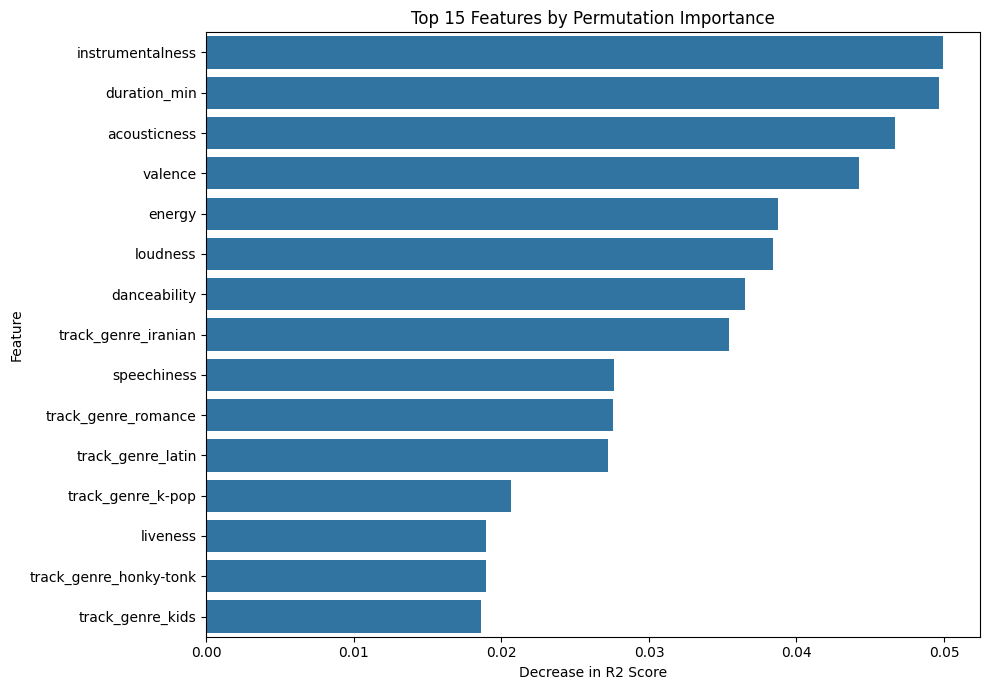

In [33]:
top15_perm_features = permutation_importance_df.head(15)

plt.figure(figsize=(10, 7))
sns.barplot(data=top15_perm_features, x="Importance", y="Feature")
plt.title("Top 15 Features by Permutation Importance")
plt.xlabel("Decrease in R2 Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### **Permutation Importance Interpretation**
- The permutation importance results show which features the trained Random Forest depends on most when making popularity predictions.

- Features with higher importance cause a larger drop in R2 score when shuffled, meaning the model loses more predictive information without them.

- This approach is simple and suitable for the scope of this project. It gives a global explanation of the model, but it does not explain individual song predictions.

- If the top features are mostly audio characteristics such as liveness, tempo, danceability, loudness, or valence, the model is mainly using measurable musical properties. If genre dummy variables appear near the top, genre also contributes meaningfully to predicted popularity.

## **Consumer Listening Behavior and Practical Implications**
- Based on the popularity prediction results and permutation importance analysis, consumer listening behavior appears to be strongly influenced by audio characteristics related to energy, rhythm, emotional atmosphere, and listener engagement. Features such as liveness, danceability, tempo, loudness, and valence play important roles in determining music popularity on digital platforms.

- The findings suggest that listeners tend to prefer songs that are energetic, rhythmic, emotionally engaging, and suitable for modern digital music consumption behaviors such as streaming, workouts, short-form videos, and live entertainment experiences.

- From a **practical perspective**, **music producers and artists** may use these insights to develop songs that better align with audience preferences and current market trends. In addition, event organizers and entertainment managers may also apply these findings when selecting music for concerts, festivals, and entertainment events to enhance audience engagement and emotional atmosphere.

**In conclusion**, the analysis not only supports music popularity prediction but also provides meaningful insights into consumer listening behavior and decision-making within the music and entertainment industry.

## **Saving model**

In [ ]:
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

MODEL_PATH = MODEL_DIR / "random_forest_regressor_model.pkl"

with open(MODEL_PATH, "wb") as file:
    pickle.dump(best_rf, file)

print(f"Model saved to: {MODEL_PATH}")

Model saved to: c:\Users\Admin\OneDrive - National Economics University\Desktop\File final\Bước 3\models\random_forest_regressor_model.pkl
